In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [2]:
DATA_PATH = "remoteok_jobs_cleaned.csv"
OUTPUT_DIR = "visualizations"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv("remoteok_jobs_cleaned.csv")
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [3]:
df.head()


,title,company,location,skills,url
0,account executive,qualio,north america,"saas, salesforce, growth, management, sales, e...",https://remoteok.com/remote-jobs/remote-accoun...
1,associate technical support engineer,recharge,remote,"technical, support, engineer",https://remoteok.com/remote-jobs/remote-associ...
2,senior software engineer,bugcrowd,india,"software, design, security, cloud, api, senior...",https://remoteok.com/remote-jobs/remote-senior...
3,staff software engineer,malt,france,"software, design, technical, support, code, ja...",https://remoteok.com/remote-jobs/remote-staff-...
4,espresso,espresso,remote,NaN,https://remoteok.com/remote-jobs/remote-espres...


## Analysis 1: Overall Skill Demand

This analysis identifies the most frequently requested skills across all
remote job postings. It helps understand which skills dominate the current
remote job market.


In [4]:
skills_df = df[['skills']].dropna()
skills_df['skills'] = skills_df['skills'].str.split(', ')
skills_df = skills_df.explode('skills')

top_skills = skills_df['skills'].value_counts().head(10)
top_skills


skills
support          41
engineer         33
technical        31
software         31
senior           29
engineering      28
growth           26
digital nomad    23
lead             22
management       22
Name: count, dtype: int64

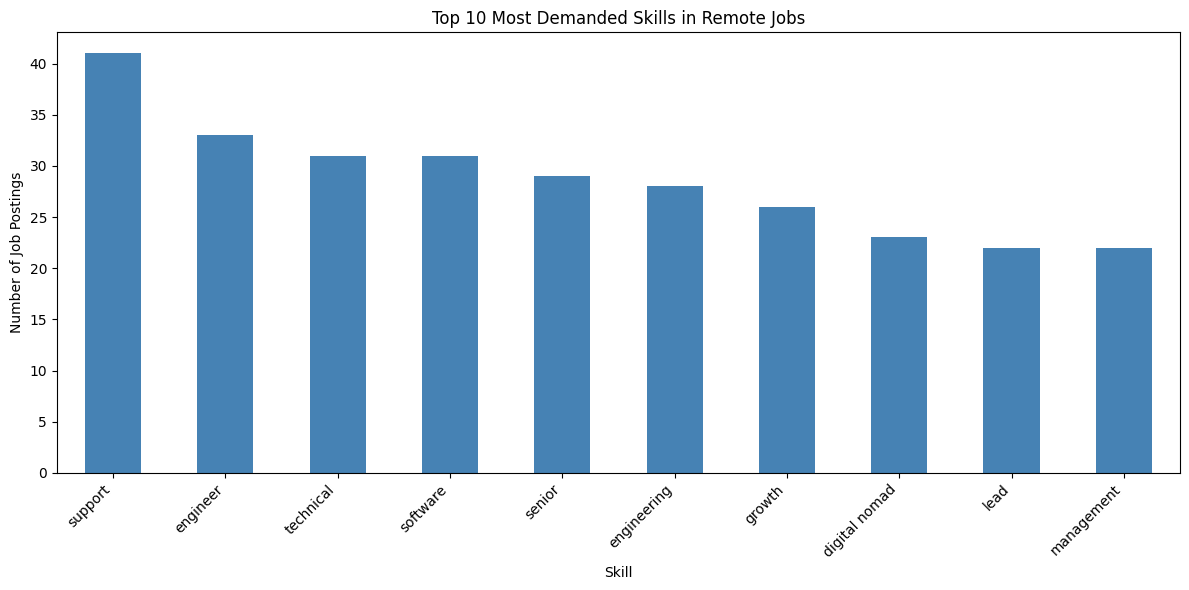

In [5]:
plt.figure(figsize=(12, 6))
top_skills.plot(kind='bar', color='steelblue')
plt.title("Top 10 Most Demanded Skills in Remote Jobs")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_skills.png", dpi=300)
plt.show()


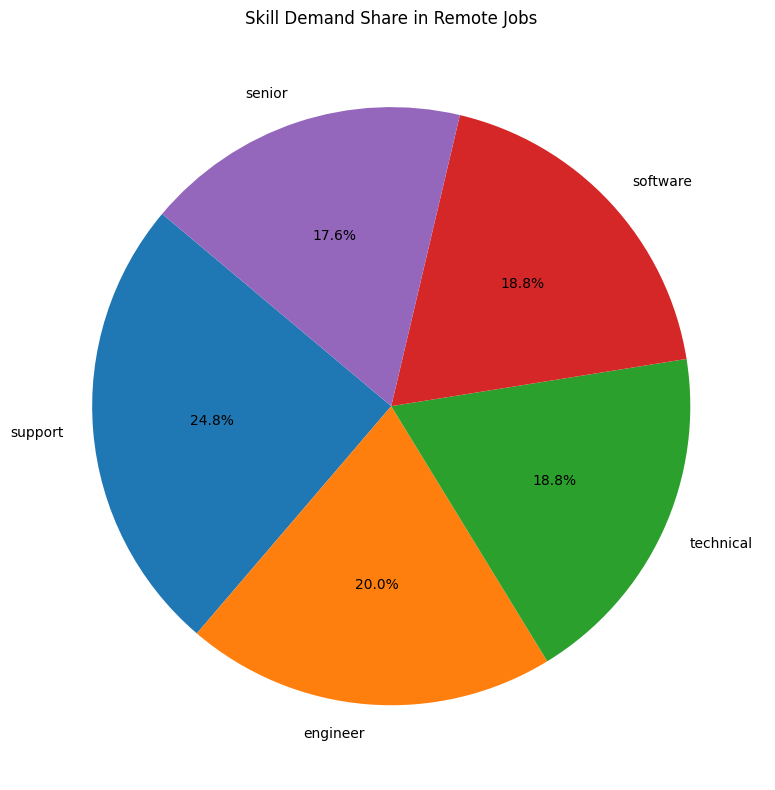

In [6]:
top_skills_pie = skills_df['skills'].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    top_skills_pie,
    labels=top_skills_pie.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Skill Demand Share in Remote Jobs")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/skill_share_pie.png", dpi=300)
plt.show()


## Analysis 2: Skill Demand Across Job Titles

This analysis compares required skills across the most common job titles
to understand role-specific skill specialization.


In [7]:
top_titles = df['title'].value_counts().head(3).index.tolist()

for title in top_titles:
    title_jobs = df[df['title'] == title]
    title_skills = title_jobs[['skills']].dropna()
    title_skills['skills'] = title_skills['skills'].str.split(', ')
    title_skills = title_skills.explode('skills')

    print(f"\nTop skills for '{title}':")
    print(title_skills['skills'].value_counts().head(5))



Top skills for 'senior software engineer':
skills
software       2
design         2
cloud          2
senior         2
engineering    2
Name: count, dtype: int64

Top skills for 'senior data engineer':
skills
senior         2
engineer       2
engineering    2
crypto         1
operational    1
Name: count, dtype: int64

Top skills for 'associate technical support engineer':
skills
technical    1
support      1
engineer     1
Name: count, dtype: int64


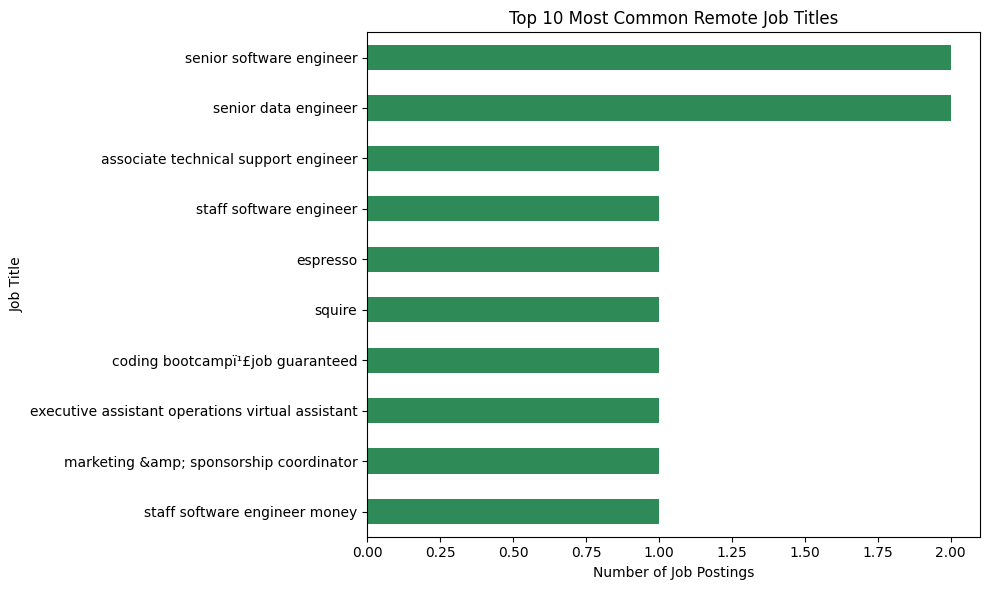

In [8]:
top_job_titles = df['title'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_job_titles.plot(kind='barh', color='seagreen')
plt.title("Top 10 Most Common Remote Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_job_titles.png", dpi=300)
plt.show()


## Analysis 3: Remote Job Distribution by Location

This analysis examines whether remote job opportunities are globally distributed
or concentrated in specific regions.


In [9]:
location_counts = df['location'].value_counts()
location_percentages = (location_counts / len(df) * 100).round(2)

for location, count in location_counts.head(10).items():
    print(f"{location}: {count} jobs ({location_percentages[location]}%)")

print(f"\nTop 5 locations account for {location_percentages.head(5).sum()}% of all jobs.")


remote: 33 jobs (33.0%)
united states: 12 jobs (12.0%)
san francisco: 3 jobs (3.0%)
new york city: 2 jobs (2.0%)
palo alto: 2 jobs (2.0%)
india: 2 jobs (2.0%)
remote - north america: 2 jobs (2.0%)
london: 2 jobs (2.0%)
remote - united states: 2 jobs (2.0%)
remote - us: 2 jobs (2.0%)

Top 5 locations account for 52.0% of all jobs.


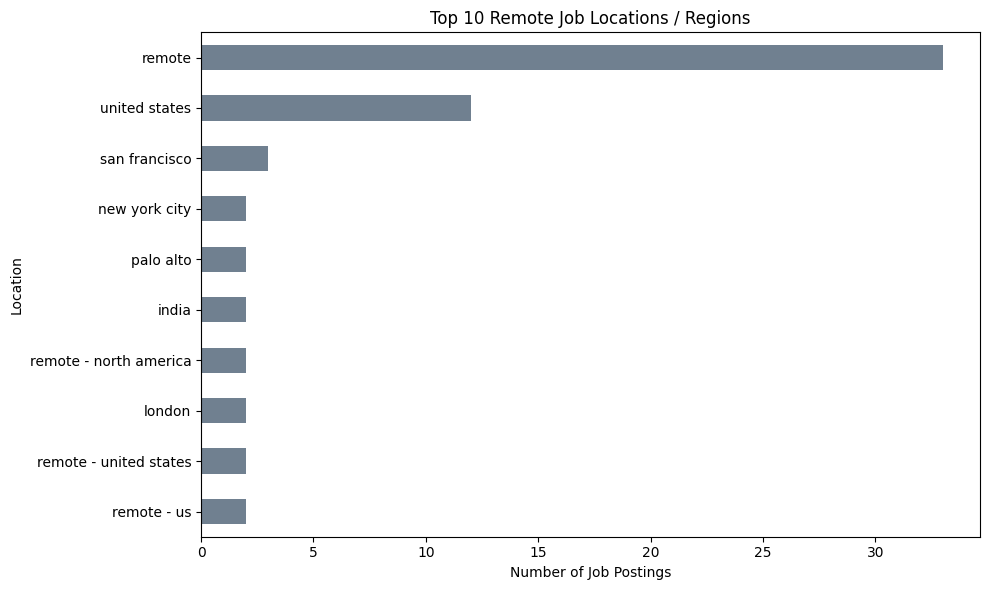

In [10]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_locations.plot(kind='barh', color='slategray')
plt.title("Top 10 Remote Job Locations / Regions")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_locations.png", dpi=300)
plt.show()


## Final Insights

- Technical skills such as Python and related technologies dominate the remote job market.
- Certain job titles consistently demand specialized skill sets, highlighting role-based specialization.
- Remote job opportunities are concentrated in a few regions, though global opportunities exist.

These insights can help job seekers prioritize skill development, educators align curricula
with market demand, and recruiters benchmark hiring trends.
